<div>
<img src=https://www.institutedata.com/wp-content/uploads/2019/10/iod_h_tp_primary_c.svg width="300">
</div>

# Lab 5.1.1
# *Evaluating Classification Models*

In this lab you will be practicing evaluating classification models (Logistic Regression in particular) on a "Breast Cancer" data.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

### 1. Load Data

From UCI's Machine Learning Repository: https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

Features are computed from a digitized image of a fine needle aspirate (FNA) of a breast mass. They describe characteristics of the cell nuclei present in the image. n the 3-dimensional space is that described in: [K. P. Bennett and O. L. Mangasarian: "Robust Linear Programming Discrimination of Two Linearly Inseparable Sets", Optimization Methods and Software 1, 1992, 23-34].

This database is also available through the UW CS ftp server: ftp ftp.cs.wisc.edu cd math-prog/cpo-dataset/machine-learn/WDBC/


Attribute Information:

1) ID number 2) Diagnosis (M = malignant, B = benign) 3-32)

Ten real-valued features are computed for each cell nucleus:

    a) radius (mean of distances from center to points on the perimeter)
    b) texture (standard deviation of gray-scale values)
    c) perimeter
    d) area
    e) smoothness (local variation in radius lengths)
    f) compactness (perimeter^2 / area - 1.0)
    g) concavity (severity of concave portions of the contour)
    h) concave points (number of concave portions of the contour)
    i) symmetry
    j) fractal dimension ("coastline approximation" - 1)

The mean, standard error and "worst" or largest (mean of the three largest values) of these features were computed for each image, resulting in 30 features. For instance, field 3 is Mean Radius, field 13 is Radius SE, field 23 is Worst Radius.

All feature values are recoded with four significant digits.

Missing attribute values: none

Class distribution: 357 benign, 212 malignant

In [3]:
breast_cancer_csv = 'breast-cancer-wisconsin-data.csv'

### 2. EDA

Explore dataset. Check for nulls. Make the target column binary.

In [6]:
df = pd.read_csv(breast_cancer_csv)

# 2. Explore the dataset
print("--- Dataset Info ---")
df.info()

# 3. Check for null values
print("\n--- Missing values per column ---")
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0])

# 4. Data Cleaning
# The 'Unnamed: 32' column is typically empty in this CSV format
if 'Unnamed: 32' in df.columns:
    df = df.drop(columns=['Unnamed: 32'])
    print("\nAction: Removed empty 'Unnamed: 32' column.")

# 5. Make the target column binary
# Mapping: Malignant (M) -> 1, Benign (B) -> 0
df['diagnosis_binary'] = df['diagnosis'].map({'M': 1, 'B': 0})

# 6. Verify and Preview
print("\n--- Target Distribution ---")
print(df['diagnosis_binary'].value_counts())

print("\n--- Data Preview ---")
print(df[['id', 'diagnosis', 'diagnosis_binary']].head())

# 7. Save the processed data
df.to_csv('breast_cancer_processed.csv', index=False)

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se    

### 3. Logistic Regression Model
In this section we fit and then evaluate a logistic regression model using a number of performance metrics.

#### 3.1 Perform a train-test split and fit a logistic regression model to the training set.

In [ ]:
# Define X and y

In [7]:
X = df.drop(columns=['id', 'diagnosis', 'diagnosis_binary'])
y = df['diagnosis_binary']

# 2. Split the data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Feature Scaling
# Logistic regression performs better when numerical features are on the same scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Initialize and fit the Logistic Regression model
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)

# 5. Make predictions and check performance
y_pred = log_reg.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Accuracy: 0.9737


#### 3.2 Calculate the predicted labels and predicted probabilities on the test set.

In [8]:
# 1. Predict the test class labels (0 or 1)
y_pred = log_reg.predict(X_test_scaled)

# 2. Predict the test probabilities
# Returns an array with [Probability of 0, Probability of 1] for each row
y_prob = log_reg.predict_proba(X_test_scaled)

# 3. View results for the first few test samples
import pandas as pd

results = pd.DataFrame({
    'Actual Class': y_test,
    'Predicted Class': y_pred,
    'Probability (Malignant)': y_prob[:, 1]
})

print(results.head())

     Actual Class  Predicted Class  Probability (Malignant)
204             0                0                 0.113590
70              1                1                 0.999991
131             1                1                 0.996921
431             0                0                 0.000510
540             0                0                 0.000061


#### 3.3 Create the confusion matrix for your classifier's performance on the test set.

Convert confusion_matrix to a dataframe.

    columns=['predicted_healthy', 'predicted_cancer']
    index=['is_healthy', 'is_cancer']

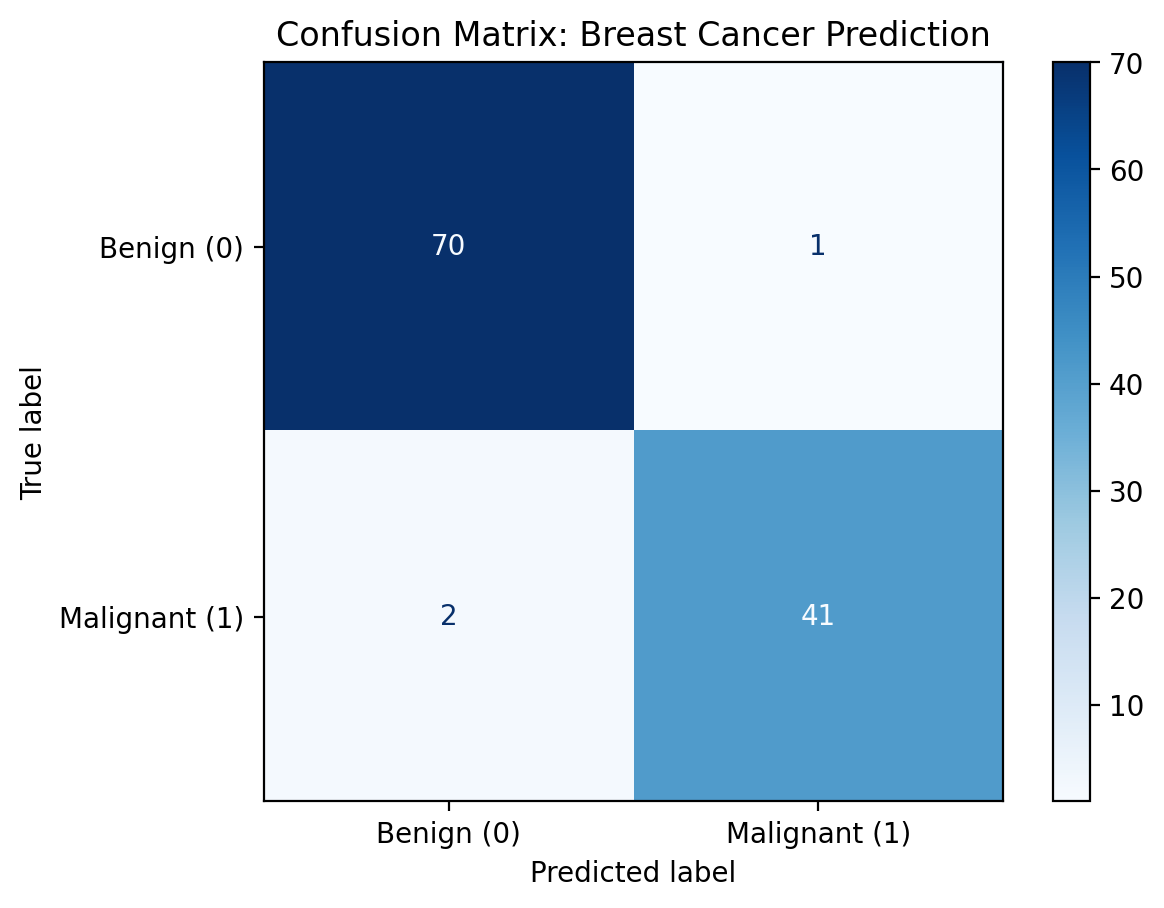

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 2. Display the matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=['Benign (0)', 'Malignant (1)'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Breast Cancer Prediction')
plt.show()

#### 3.4 Calculate Accuracy

**Classification Accuracy:** Overall, how often is the classifier correct?

    (TP + TN) / float(TP + TN + FP + FN)

In [ ]:
# See 3.1

#### 3.5 Calculate Classification Error

**Classification Error:** Overall, how often is the classifier incorrect?

Also known as "Misclassification Rate"

    (FP + FN) / float(TP + TN + FP + FN)

In [11]:
from sklearn.metrics import accuracy_score

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Calculate classification error
error = 1 - accuracy

print(f"Classification Error: {error:.4f}")
print(f"Error Percentage: {error * 100:.2f}%")

Classification Error: 0.0263
Error Percentage: 2.63%


#### 3.6 Calculate Sensitivity

**Sensitivity:** When the actual value is positive, how often is the prediction correct?

Something we want to maximize
How "sensitive" is the classifier to detecting positive instances?
- Also known as "True Positive Rate" or "Recall"
- TP / all positive
    - all positive = TP + FN

    sensitivity = TP / float(FN + TP)

In [12]:
from sklearn.metrics import recall_score

# 1. Calculate sensitivity (recall) using sklearn's built-in function
# By default, for binary classification, it calculates it for the '1' class
sensitivity = recall_score(y_test, y_pred)

print(f"Sensitivity (Recall): {sensitivity:.4f}")

# 2. Manual calculation using the confusion matrix (TP / (TP + FN))
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
manual_sensitivity = tp / (tp + fn)

print(f"Manual Sensitivity Calculation: {manual_sensitivity:.4f}")

Sensitivity (Recall): 0.9535
Manual Sensitivity Calculation: 0.9535


#### 3.7 Calculate Specificity

**Specificity:** When the actual value is negative, how often is the prediction correct?

- Something we want to maximize. How "specific" (or "selective") is the classifier in predicting positive instances?
- TN / all negative
    - all negative = TN + FP

    specificity = TN / (TN + FP)

In [13]:
from sklearn.metrics import confusion_matrix

# 1. Extract values from confusion matrix
# ravel() returns tn, fp, fn, tp for binary classification
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# 2. Calculate Specificity
specificity = tn / (tn + fp)

print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"Specificity: {specificity:.4f}")

True Negatives: 70
False Positives: 1
Specificity: 0.9859


#### 3.8 Calculate False Positive Rate

**False Positive Rate:** When the actual value is negative, how often is the prediction incorrect?

    false_positive_rate = FP / float(TN + FP)

In [14]:
from sklearn.metrics import confusion_matrix

# 1. Extract values from the confusion matrix
# ravel() returns tn, fp, fn, tp for binary classification
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# 2. Calculate the False Positive Rate (FPR)
# Formula: FPR = FP / (FP + TN)  or  1 - Specificity
fpr = fp / (fp + tn)

print(f"False Positives (FP): {fp}")
print(f"True Negatives (TN): {tn}")
print(f"False Positive Rate: {fpr:.4f}")
print(f"False Positive Rate Percentage: {fpr * 100:.2f}%")

False Positives (FP): 1
True Negatives (TN): 70
False Positive Rate: 0.0141
False Positive Rate Percentage: 1.41%


#### 3.9 Calculate Precision

**Precision:** When a positive value is predicted, how often is the prediction correct?

How "precise" is the classifier when predicting positive instances?

    precision = TP / float(TP + FP)

In [15]:
from sklearn.metrics import precision_score, confusion_matrix

# 1. Calculate using sklearn's built-in function
precision = precision_score(y_test, y_pred)

# 2. Manual calculation for demonstration
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
manual_precision = tp / (tp + fp)

print(f"Precision: {precision:.4f}")
print(f"Manual Precision: {manual_precision:.4f}")

Precision: 0.9762
Manual Precision: 0.9762


#### 3.10 Create a predicted test probability dataframe with column names 'class_0_pp','class_1_pp'

In [16]:
import pandas as pd

# Create the DataFrame from the y_prob array
# y_prob contains [probability_of_class_0, probability_of_class_1]
prob_df = pd.DataFrame(y_prob, columns=['class_0_pp', 'class_1_pp'])

# Display the first few rows
print(prob_df.head())

   class_0_pp  class_1_pp
0    0.886410    0.113590
1    0.000009    0.999991
2    0.003079    0.996921
3    0.999490    0.000510
4    0.999939    0.000061


#### 3.11 The Receiver operating characteristic (ROC) curve

Plot the ROC curve for Class 1

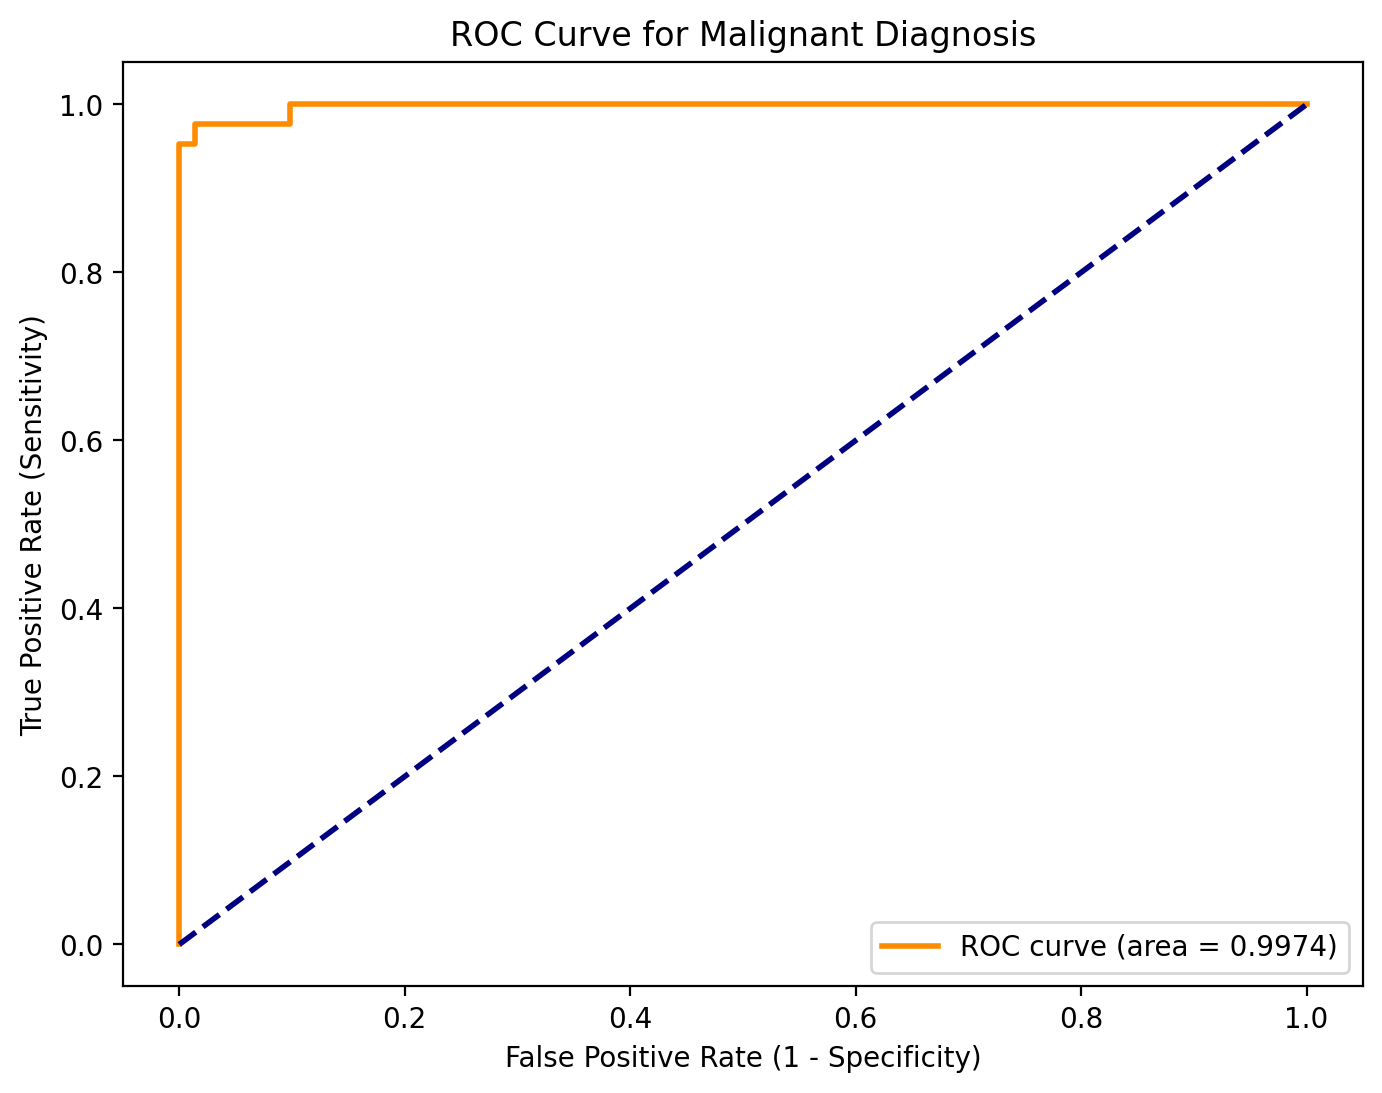

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. Calculate FPR, TPR, and thresholds for Class 1 (Malignant)
# y_score is the predicted probability of the positive class
y_score = log_reg.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

# 2. Plotting
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Diagonal random baseline
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve for Malignant Diagnosis')
plt.legend(loc="lower right")
plt.show()

**References**

[Breast Cancer Wisconsin (Diagnostic) Data Set](https://www.kaggle.com/uciml/breast-cancer-wisconsin-data/downloads/breast-cancer-wisconsin-data.zip/2)

[Validation curves: plotting scores to evaluate models](https://scikit-learn.org/stable/modules/learning_curve.html#learning-curves)



---



---



> > > > > > > > > © 2026 Institute of Data


---



---



